Signal is stereophonic


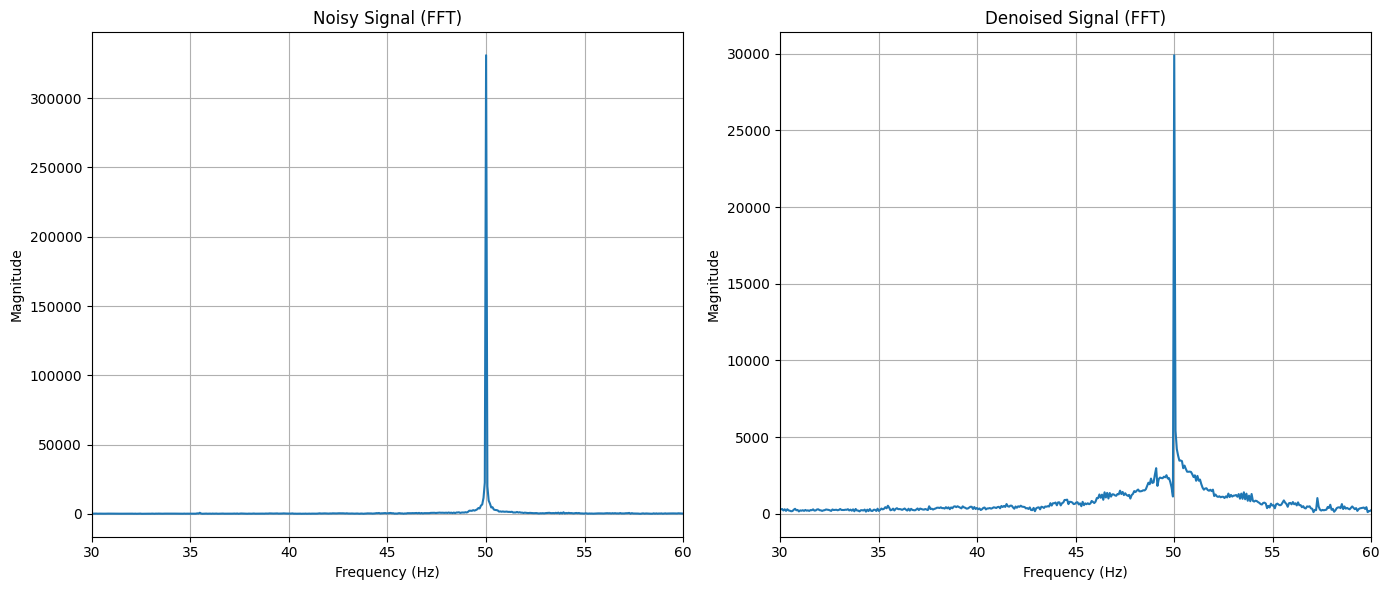

In [ ]:
# Implementation part 1: Noise cancelling: Method #1: Adaptive Filtering

from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq


def adaptive_lms(noisy_signal, noise, filter_taps = 32, learning_rate = 0.00001):
    # Adaptive filter is actually an FIR with varying coefficients
    # Assuming that the FIR filter is as y(n) = sum from k=0 to k=M-1 [w_k.x(n-k)], M is defined to be 'the number of taps of the filter'

    # The procedure is:
    # 1. Getting the filter output y(n) each time
    # 2. Computing the error: e(n) = d(n) - y(n)  (where d(n) is the noisy signal)
    # 3. Weight Update Rule: w(n+1) = w(n) + x(n) . e(n) . learning_rate

    N = len(noisy_signal)
    # Initialize weight signal and stuff!
    w = np.zeros(filter_taps)
    error = np.zeros(N)

    # since we are trying to access x(n-1), x(n-2), ..., it's necessary to pad the vector with zeros first
    x_padded = np.concatenate((np.zeros(filter_taps-1), noise))
    for n in range(N):
        x_vec = x_padded[n:n+filter_taps][::-1]     # to get x(n), x(n-1), ..., x(n-M+1)
        y = np.dot(w, x_vec)  # do dot product (this is the filter output for one sample)
        # calculate the error
        e = noisy_signal[n] - y # this is the difference between the noisy signal and the estimated noise for one sample
        # Weight Update Rule: w(n+1) = w(n) + x(n) . e(n) . learning_rate
        w +=  learning_rate * e * x_vec

        error[n] = e # thus 'error' is a vector of the difference between the noisy signal and the expected noise at all time => 'error'
        # is the denoised signal
    return error


# A function for plotting the FFT of the signal (later discussed)
def plot_fft(signal, sample_rate, title):
    N = len(signal)
    yf = np.abs(fft(signal))[:N // 2]
    xf = fftfreq(N, 1 / sample_rate)[:N // 2]
    plt.plot(xf, yf)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.xlim(30, 60)    # there are also frequencies much higher than this, but this interval was chosen to 
    # emphasize the behavior around 50Hz, where we've done cancellation 


##############################  1. laod the recorded audio file
# Load WAV
audio = AudioSegment.from_wav("project_audio.wav")

# Get raw data as array of samples
samples = np.array(audio.get_array_of_samples())


# Extracting the properties of the audio:
sample_rate = audio.frame_rate
channels = audio.channels

# Handle stereo audio (2 channels)
if channels == 2:
    print('Signal is stereophonic')
    samples = samples.reshape((-1, 2))
else:
    print('Signal is monophonic')

# Save original dtype before normalization
original_dtype = np.int16  # Assuming 16-bit PCM
samples = samples.astype(np.float64)
samples /= np.max(np.abs(samples))  # Normalize to -1.0 to 1.0


##############################  2. Adding power line noise to the signal
# As mentioned in part E, 1.1.2 of the report, power line noise can be modeled as n(t)=Asin(2pift)
# First vcreating a time vector
num_samples = samples.shape[0]
t = np.arange(num_samples) / sample_rate 
# In Iran, the frequency of the power line noise is 50Hz
frequency = 50
# About the amplitude of the power line noise: power line noise amplitude can be from 10 microvolts to a few volts. So 1V is probably a good estimation.
# Here, we want the noise to be hearable. Since the inout signal is already normalized, we can assume:
amplitude = 1
power_line = amplitude * np.sin(2 * np.pi * frequency * t)

# Ensure sine wave matches data type of audio
# power_line = power_line.astype(samples.dtype)

# If stereo, expand power_line to both channels by duplicating along axis 1
if channels == 2:
    power_line = np.stack((power_line, power_line), axis=1)

# Add sine wave to audio samples
noisy_signal = samples + power_line

# Clip to prevent integer overflow
noisy_signal = np.clip(noisy_signal, -1.0, 1.0)

# Scale the audio back, bc we normalized it at first 
noisy_to_save = (noisy_signal * 32767).astype(np.int16)

# Save the noisy audio file, maybe we can compare them by ear (turns out we can't, thought as much though!)
noisy_audio = AudioSegment(
    # convert the denoised signal to the wav file standard
    noisy_to_save.tobytes(),
    frame_rate = sample_rate,
    sample_width = 2,
    channels = channels #keep the channels number
)

noisy_audio.export("project_audio_noisy_version.wav", format  = "wav")



############################## 3. Implement the adaptive filtering algorithm to remove the power line noise from the recorded signal
##############################    Use the LMS loss function and Gradient Descent algorithm.

if channels == 2:
    # in case it is stereo, we need to apply the LMS algoritm to both channels
    denoised_left = adaptive_lms(noisy_signal[:, 0], power_line[:, 0])
    denoised_right = adaptive_lms(noisy_signal[:, 1], power_line[:, 1])
    denoised = np.stack((denoised_left, denoised_right), axis=1)
else:
    denoised = adaptive_lms(noisy_signal, power_line)

# Now saving the denoised output
# Clip + Scale back for saving
denoised = np.clip(denoised, -1.0, 1.0)
denoised_to_save = (denoised * 32767).astype(np.int16)

denoised_audio = AudioSegment(
    # convert the denoised signal to the wav file standard
     denoised_to_save.tobytes(),
    frame_rate = sample_rate,
    sample_width = 2,
    channels = channels #keep the channels number
)

denoised_audio.export("lms noise cancelling.wav", format  = "wav")

# So, let's showcase the difference by taking the FFT of the noisy audio signal before and after noise cancelling. (Although it is also detectable by ear)

# Choose one channel if stereo
if channels == 2:
    orig = samples[:, 0]
    noisy = noisy_signal[:, 0]
    denoised = denoised[:, 0]
else:
    orig = samples
    noisy = noisy_signal
    denoised = denoised

# Plotting
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_fft(noisy, sample_rate, 'Noisy Signal (FFT)')

plt.subplot(1, 2, 2)
plot_fft(denoised, sample_rate, 'Denoised Signal (FFT)')

plt.tight_layout()
plt.show()


# Now in the results, we can see that the magnitude of FFT has reduced around 50Hz.

Signal is stereophonic


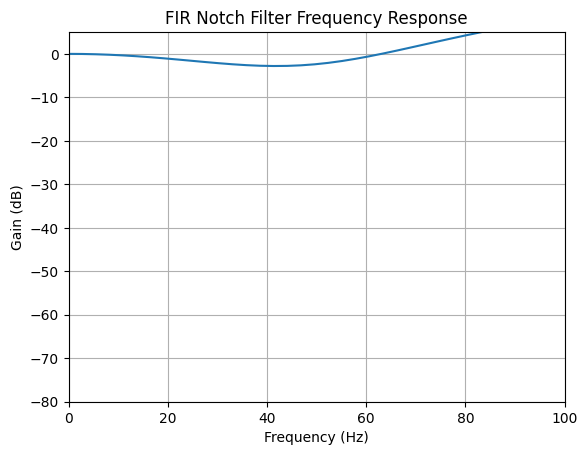

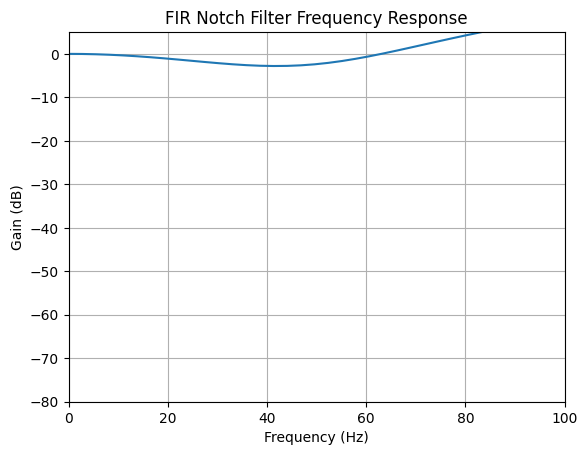

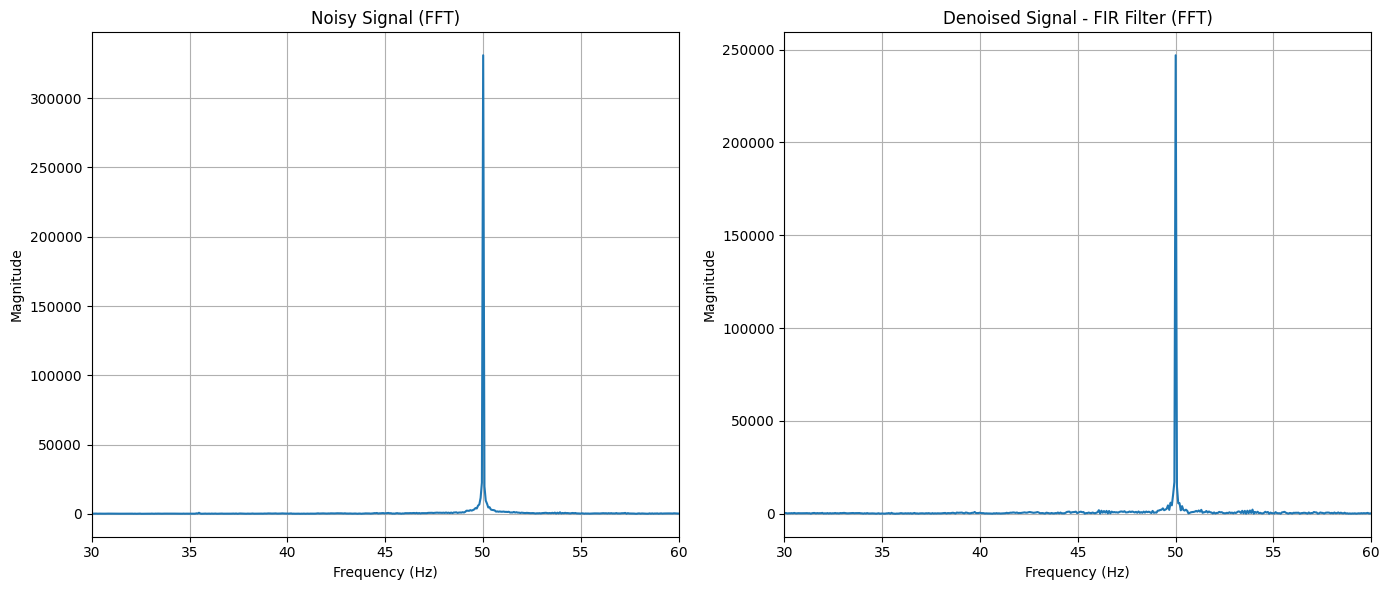

In [ ]:
# Implementation part 1: Noise cancelling: Method #2: FIR Filter

from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import firwin, lfilter
from scipy.signal import freqz

def plot_filter_response(taps, sample_rate):
    w, h = freqz(taps, worN=8000)
    freqs = w * sample_rate / (2 * np.pi)
    plt.figure()
    plt.plot(freqs, 20 * np.log10(np.abs(h)))
    plt.title("FIR Notch Filter Frequency Response")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Gain (dB)")
    plt.grid(True)
    plt.xlim(0, 100)
    plt.ylim(-80, 5)
    plt.show()


def fir_notch_filter(noisy_signal, sample_rate_in_Hz, notch_freq, num_taps, bandwidth):
    
    """
    Parameters:
        noisy_signal (np.array): The input noisy signal.
        sample_rate_in_Hz (float): Sample rate of the signal.
        notch_freq (float): Frequency to notch out (e.g., 50Hz).
        num_taps (int): Number of filter taps (FIR filter order).
        bandwidth (float): Width of the notch in Hz.

    Returns:
        filtered (np.array): The filtered signal.
    """
    # Define the band edges for the stop band
    nyquist = sample_rate_in_Hz / 2
    low = notch_freq - bandwidth / 2
    high = notch_freq + bandwidth / 2

    # Design the band-stop filter
    band = [low, high]
    taps = firwin(num_taps, band, window='hamming', pass_zero='bandstop', fs=sample_rate_in_Hz)

    # Apply the FIR filter to the signal
    filtered = lfilter(taps, 1.0, noisy_signal)

    # show the functionality of tyhe filter
    plot_filter_response(taps, sample_rate_in_Hz)
    return filtered


# A function for plotting the FFT of the signal (later discussed)
def plot_fft(signal, sample_rate, title):
    N = len(signal)
    yf = np.abs(fft(signal))[:N//2]
    xf = fftfreq(N, 1/sample_rate)[:N//2]
    plt.plot(xf, yf)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.xlim(30, 60)    # there are also frequencies much higher than this, but this interval was chosen to 
    # emphasize the behavior around 50Hz, where we've done cancellation 


##############################  1. laod the recorded audio file
# Load WAV
audio = AudioSegment.from_wav("project_audio.wav")

# Get raw data as array of samples
samples = np.array(audio.get_array_of_samples())

# Extracting the properties of the audio:
sample_rate = audio.frame_rate
channels = audio.channels

# Handle stereo audio (2 channels)
if channels == 2:
    print('Signal is stereophonic')							   
    samples = samples.reshape((-1, 2))
else:
    print('Signal is monophonic')

# Save original dtype before normalization
original_dtype = np.int16  # Assuming 16-bit PCM
samples = samples.astype(np.float64)
samples /= np.max(np.abs(samples))  # Normalize to -1.0 to 1.0


##############################  2. Adding power line noise to the signal
# As mentioned in part E, 1.1.2 of the report, power line noise can be modeled as n(t)=Asin(2pift)
# First vcreating a time vector
num_samples = samples.shape[0]
t = np.arange(num_samples) / sample_rate 
# In Iran, the frequency of the power line noise is 50Hz
frequency = 50
# Explained before why 1 is a good number for the amplitude of the power line noise.
amplitude = 1
power_line = amplitude * np.sin(2 * np.pi * frequency * t)

# Ensure sine wave matches data type of audio
# power_line = power_line.astype(samples.dtype)

# If stereo, expand power_line to both channels by duplicating along axis 1
if channels == 2:
    power_line = np.stack((power_line, power_line), axis=1)

# Add sine wave to audio samples
noisy_signal = samples + power_line

# Clip to prevent integer overflow
noisy_signal = np.clip(noisy_signal, -1.0, 1.0)
													 
# Scale the audio back, bc we normalized it at first 
noisy_to_save = (noisy_signal * 32767).astype(np.int16)													   

# Save the noisy audio file, maybe we can compare them by ear (turns out we can't, thought as much though!)
noisy_audio = AudioSegment(
    # convert the denoised signal to the wav file standard
    noisy_to_save.tobytes(),
    frame_rate = sample_rate,
    sample_width = 2,
    channels = channels #keep the channels number
)

noisy_audio.export("project_audio_noisy_version.wav", format  = "wav")



############################## 3. Implement an FIR filter to remove the power line noise from the recorded signal
# Here we design a band-stop (notch filter) centered at 50Hz, to eliminate (strongly attenuate) the 50Hz power line noise. (the fir_notch_filter function)
notch_freq = 50 # 50Hz is the frequency we need to notch out
bandwidth = 80
num_taps = 1001

# now if the sound is stereo, apply the filter to both channels
																						   

if channels == 2:
    denoised_left = fir_notch_filter(noisy_signal[:, 0], sample_rate, notch_freq, num_taps, bandwidth)
    denoised_right = fir_notch_filter(noisy_signal[:, 1], sample_rate, notch_freq, num_taps, bandwidth)
    denoised = np.stack((denoised_left, denoised_right), axis=1)
else:
    denoised = fir_notch_filter(noisy_signal, sample_rate, notch_freq, num_taps, bandwidth)

# Saving the filtered audio
# Clip + Scale back for saving
denoised = np.clip(denoised, -1.0, 1.0)
denoised_to_save = (denoised * 32767).astype(np.int16)
denoised_audio = AudioSegment(
    # convert the denoised signal to the wav file standard
    denoised_to_save.tobytes(),
    frame_rate=sample_rate,
    sample_width=2,
    channels=channels
)

denoised_audio.export("fir noise cancelling.wav", format="wav")

# Plotting the FFT of the noisy and denoised signal
# Choose one channel if stereo
if channels == 2:	
    noisy = noisy_signal[:, 0]
    denoised_plot = denoised[:, 0]
else:	  
    noisy = noisy_signal
    denoised_plot = denoised

		  
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_fft(noisy, sample_rate, 'Noisy Signal (FFT)')

plt.subplot(1, 2, 2)
plot_fft(denoised_plot, sample_rate, 'Denoised Signal - FIR Filter (FFT)')

plt.tight_layout()
plt.show()
						   

Signal is stereophonic


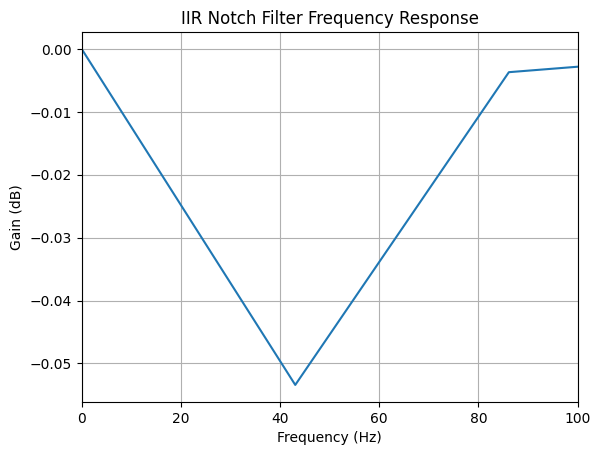

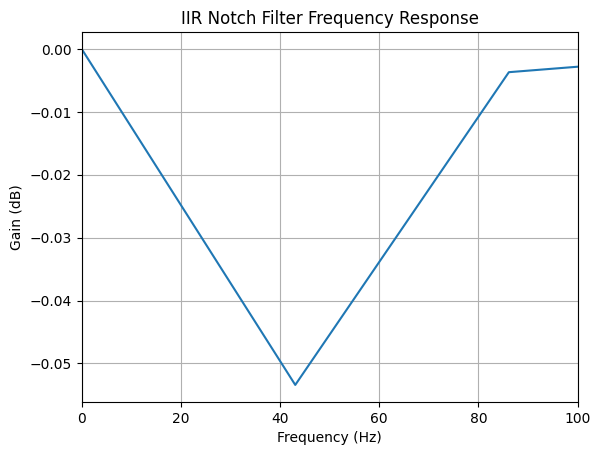

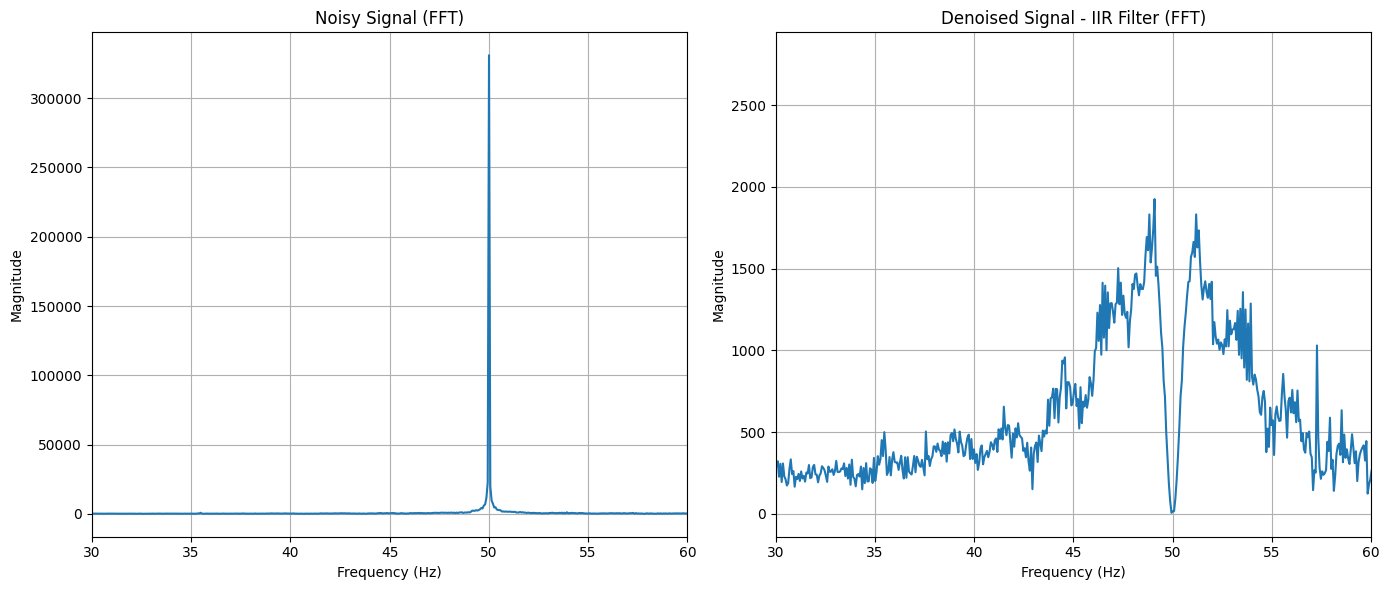

In [ ]:
# Implementation part 1: Noise cancelling: Method #3: IIR Filter

from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import iirnotch
from scipy.signal import freqz

def plot_filter_response(notch_freq, Quality_factor, sample_rate):
    b, a = iirnotch(w0 = notch_freq, Q = Quality_factor, fs = sample_rate)
    w, h = freqz(b, a, fs = sample_rate)

    plt.figure()
    plt.plot(w, 20 * np.log10(np.abs(h)))
    plt.title("IIR Notch Filter Frequency Response")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Gain (dB)")
    plt.grid(True)
    plt.xlim(0, 100)
    # plt.ylim(-80, 5)
    plt.show()


def iir_notch_filter(noisy_signal, sample_rate_in_Hz, notch_freq, quality_factor, num_stages):
    """
    Apply a high-order IIR notch filter by cascading multiple second-order sections (biquads).

    Parameters:
        noisy_signal (np.array): Input noisy signal.
        sample_rate_in_Hz (float): Sampling frequency.
        notch_freq (float): Frequency to remove (e.g., 50 Hz).
        quality_factor (float): Q-factor for each biquad.
        num_stages (int): Number of biquad sections to cascade => total filter order = 2 * num_stages.

    Returns:
        filtered (np.array): Filtered output signal.
    """
    from scipy.signal import sosfilt
    import numpy as np

    # Create multiple second-order sections
    sos = []
    for _ in range(num_stages):
        b, a = iirnotch(w0=notch_freq, Q=quality_factor, fs=sample_rate_in_Hz)
        sos.append([*b, *a])  # Flatten b and a into a single SOS row

    # Convert to np.array in SOS format
    sos = np.array(sos)

    # Apply cascaded biquad filtering
    filtered = sosfilt(sos, noisy_signal)

    plot_filter_response(notch_freq, quality_factor, sample_rate_in_Hz)
    return filtered



# A function for plotting the FFT of the signal (later discussed)
def plot_fft(signal, sample_rate, title):
    N = len(signal)
    yf = np.abs(fft(signal))[:N//2]
    xf = fftfreq(N, 1/sample_rate)[:N//2]
    plt.plot(xf, yf)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.xlim(30, 60)    # there are also frequencies much higher than this, but this interval was chosen to 
    # emphasize the behavior around 50Hz, where we've done cancellation 


##############################  1. laod the recorded audio file
# Load WAV
audio = AudioSegment.from_wav("project_audio.wav")

# Get raw data as array of samples
samples = np.array(audio.get_array_of_samples())

# Extracting the properties of the audio:
sample_rate = audio.frame_rate
channels = audio.channels

# Handle stereo audio (2 channels)
if channels == 2:
    print('Signal is stereophonic')							   
    samples = samples.reshape((-1, 2))
else:
    print('Signal is monophonic')

# Save original dtype before normalization
original_dtype = np.int16  # Assuming 16-bit PCM
samples = samples.astype(np.float64)
samples /= np.max(np.abs(samples))  # Normalize to -1.0 to 1.0


##############################  2. Adding power line noise to the signal
# As mentioned in part E, 1.1.2 of the report, power line noise can be modeled as n(t)=Asin(2pift)
# First vcreating a time vector
num_samples = samples.shape[0]
t = np.arange(num_samples) / sample_rate 
# In Iran, the frequency of the power line noise is 50Hz
frequency = 50
# Explained before why 1 is a good number for the amplitude of the power line noise.
amplitude = 1
power_line = amplitude * np.sin(2 * np.pi * frequency * t)

# Ensure sine wave matches data type of audio
# power_line = power_line.astype(samples.dtype)

# If stereo, expand power_line to both channels by duplicating along axis 1
if channels == 2:
    power_line = np.stack((power_line, power_line), axis=1)

# Add sine wave to audio samples
noisy_signal = samples + power_line

# Clip to prevent integer overflow
noisy_signal = np.clip(noisy_signal, -1.0, 1.0)
													 
# Scale the audio back, bc we normalized it at first 
noisy_to_save = (noisy_signal * 32767).astype(np.int16)													   

# Save the noisy audio file, maybe we can compare them by ear (turns out we can't, thought as much though!)
noisy_audio = AudioSegment(
    # convert the denoised signal to the wav file standard
    noisy_to_save.tobytes(),
    frame_rate = sample_rate,
    sample_width = 2,
    channels = channels #keep the channels number
)

noisy_audio.export("project_audio_noisy_version.wav", format  = "wav")



############################## 3. Implement an IIR filter to remove the power line noise from the recorded signal
notch_freq = 50 # 50Hz is the frequency we need to notch out
quality_factor = 30
number_of_stages = 3

# now if the sound is stereo, apply the filter to both channels
																						   
if channels == 2:
    denoised_left = iir_notch_filter(noisy_signal[:, 0], sample_rate, notch_freq, quality_factor, number_of_stages)
    denoised_right = iir_notch_filter(noisy_signal[:, 0], sample_rate, notch_freq, quality_factor, number_of_stages)
    denoised = np.stack((denoised_left, denoised_right), axis=1)
else:
    denoised = iir_notch_filter(noisy_signal[:, 0], sample_rate, notch_freq, quality_factor, number_of_stages)

# Saving the filtered audio
# Clip + Scale back for saving
denoised = np.clip(denoised, -1.0, 1.0)
denoised_to_save = (denoised * 32767).astype(np.int16)
denoised_audio = AudioSegment(
    # convert the denoised signal to the wav file standard
    denoised_to_save.tobytes(),
    frame_rate=sample_rate,
    sample_width=2,
    channels=channels
)

denoised_audio.export("iir noise cancelling.wav", format="wav")

# Plotting the FFT of the noisy and denoised signal
# Choose one channel if stereo
if channels == 2:	
    noisy = noisy_signal[:, 0]
    denoised_plot = denoised[:, 0]
else:	  
    noisy = noisy_signal
    denoised_plot = denoised

		  
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_fft(noisy, sample_rate, 'Noisy Signal (FFT)')

plt.subplot(1, 2, 2)
plot_fft(denoised_plot, sample_rate, 'Denoised Signal - IIR Filter (FFT)')

plt.tight_layout()
plt.show()
						   

In [ ]:
###################### NOW: Playing all the result files along with the noisy version back to back and comparing

import pygame
import time

# Initialize the mixer
pygame.mixer.init()

wav_files = ["project_audio_noisy_version.wav", "lms noise cancelling.wav", "fir noise cancelling.wav", "iir noise cancelling.wav"]
messages = ["The noisy audio signal...\n", "Result of Adaptive noise cancellation...\n", "Result of FIR noise cancellation...\n", "Result of IIR noise cancellation..."]

if len(messages) != len(wav_files):
    raise ValueError("There must be one message per audio file.")

for i, wav_file in enumerate(wav_files):
    print(messages[i])
    pygame.mixer.music.load(wav_file)
    pygame.mixer.music.play()
    while pygame.mixer.music.get_busy():
        time.sleep(0.1)
    if i < len(wav_files) - 1:
        time.sleep(2)  # Delay between tracks
    
pygame.mixer.quit()
print("All done!")


The noisy audio signal...

Result of Adaptive noise cancellation...

Result of FIR noise cancellation...

Result of IIR noise cancellation...
All done!
